<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-1/HW1_322512690_21239353_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 1**  - Deep Learning Winter 2024

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#**Part 1 : Binary Classification**

In this part we will predict yearly income using a Feed Forward Neural Network.

We will predict whether an individual's yearly income exceeds $50,00 based on the given dataset that containes personal attributes such as age , genderm nationality and more.

# **Loading the Data:**

In [3]:
import pandas as pd

# Define the paths to your datasets
train_path = '/content/drive/MyDrive/HW-1/part1_train.csv'
test_path = '/content/drive/MyDrive/HW-1/part1_test.csv'

names=["age","workclass","fnlwgt","education","education-num","marital-status","occupation","relationship","race","sex","capital-gain","capital-loss","hours-per-week",\
       "native-country","target"]

# Load the datasets
train_data = pd.read_csv(train_path,names=names)
test_data = pd.read_csv(test_path,names=names)

# Display 10  samples from the datasets
print("Samples from the trining Data:\n")
print(train_data.head(n=10))
print("\nSamples from the test Data:\n")
print(test_data.head(n=10))


Samples from the trining Data:

   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   
5   37            Private  284582     Masters             14   
6   49            Private  160187         9th              5   
7   52   Self-emp-not-inc  209642     HS-grad              9   
8   31            Private   45781     Masters             14   
9   42            Private  159449   Bachelors             13   

           marital-status          occupation    relationship    race  \
0           Never-married        Adm-clerical   Not-in-family   White   
1      Married-civ-spouse     Exec-managerial         Husband   White   
2                Divorced   Handlers-cleaner

# **Preprocessing the Data :**

In order to scale the data we need first to covnert non-numerical values into numerical represtnation. so what we do is we apply one-hot encoding in order to represnt them.

In [4]:

# Identify categorical columns that exist in both train and test datasets
categorical_columns = list(set(train_data.select_dtypes(include=['object']).columns) &
                           set(test_data.select_dtypes(include=['object']).columns))

# Extract target variable before encoding (assuming last column is the target)
y_train = train_data.iloc[:, -1]
y_test = test_data.iloc[:, -1]

#need to remove the '.' in order to make the data clear and now convert it to numerical.
y_test = test_data.iloc[:, -1].str.strip().str.replace('.', '', regex=False)
# Strip whitespace from target column values
y_train = y_train.str.strip()
y_test = y_test.str.strip()


# Define the mapping for target values
label_mapping = {"<=50K": 0, ">50K": 1}

# Apply the mappingt
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)


# Apply one-hot encoding separately (for training and test (without target))
train_data_encoded = pd.get_dummies(train_data, columns=categorical_columns)
test_data_encoded = pd.get_dummies(test_data, columns=categorical_columns)

# Align columns between train and test datasets to handle mismatched categories
train_data_aligned, test_data_aligned = train_data_encoded.align(test_data_encoded, join='inner', axis=1)


# **Exctract features and exclude the target for training and test and scaling the data using the StandardScaler.**

In [5]:
# Extract features (after alignment)
X_train = train_data_aligned.drop(columns=train_data_aligned.columns[-1],axis=1)  # Drop target column
X_test = test_data_aligned.drop(columns=test_data_aligned.columns[-1],axis=1)    # Drop target column


# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# # Print shapes to verify
# print("X_train_scaled shape:", X_train_scaled.shape)
# print("X_test_scaled shape:", X_test_scaled.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)


In [6]:
# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

**Now**:

we print the distribution of yearly income for the individuals and the
percentage of them more / less than 50k/year.

In [7]:
# Compute distribution for y_train
unique, counts = torch.unique(y_train, return_counts=True)

# Print the distribution
print("Income Distribution in Training Data:")
for value, count in zip(unique, counts):
    label = "<=50K" if value.item() == 0 else ">50K"
    print(f"{label}: {count.item()}")

# Compute percentages
total = counts.sum().item()
percentages = (counts.float() / total) * 100

# Print the percentages
print("\nIncome Percentage in Training Data:")
for value, percent in zip(unique, percentages):
    label = "<=50K" if value.item() == 0 else ">50K"
    print(f"{label}: {percent.item():.2f}%")


Income Distribution in Training Data:
<=50K: 24720
>50K: 7841

Income Percentage in Training Data:
<=50K: 75.92%
>50K: 24.08%


# Defining the Model :

We define a Feed Forward Netwrok for binary classifaction  with **3 layers**.


**Structure:**

input size : defined by the number of the features in the training data.

Hidden layers:

hidden layer 1: fully connected layer with 64 neurons. (input_size-> 64)

hidden layer 2: fully connected layer with 32 neurons. (64->32)

Output layer: fully connected layer with 2 neurons. (32->2)

Activation function : **ReLU** for both hidden layers.


**Note:**

We  choose to add a two dropout layer after each hidden layer with probability of 0.2 in order to reduce the risk of overfiting.


**Total num of parameters:**


input size :106( the total number of numerical features after applying one hot encoding)<br>

input to hidden layer 1 : 106x64 + 64 = 6848. <br>
hidden layer 1 to hidden layer 2: 64x32 + 32= 2080.<br>
hidden layer 2 to Output: 32x2+2= 66.<br>

**Total Parameters: 6848+2080+66 =8994.**








In [8]:
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)  # Hidden layer 1
        self.dropout1 = nn.Dropout(p=0.2)    # Dropout for regularization
        self.fc2 = nn.Linear(64, 32)         # Hidden layer 2
        self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(32, 2)          # Output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation function for first layer
        x = F.relu(self.fc2(x))  # Activation function for second layer
        x = self.fc3(x)          # No activation for output layer (raw scores)
        return x


# **Training the Model**:




1.    Hyperparameters:

      Learning Rate: 0.001.<br>
      Epochs:20.<br>
      Batch Size: 32.<br>

2.   Loss Function : Cross Entropy Loss.

3.   Optimizer: Adam.



*Note:*

 we split the training data into 80% for training and 20% for validation.




In [9]:
from torch.utils.data import TensorDataset, DataLoader, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Input size is the number of features
input_size = X_train.shape[1]

print("input size: ",input_size)

# Define the model and hyperparameters
model = FeedForwardNN(input_size).to(device)
learning_rate = 0.001
epochs = 20
batch_size = 32

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Split the training dataset into training (80%) and validation (20%)
train_dataset = TensorDataset(X_train, y_train)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

# Arrays to store metrics
train_acc = []
train_loss = []
val_acc = []
val_loss = []

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Calculate accuracy for this batch
        _, predicted = torch.max(outputs, 1)  # Get predicted classes
        correct += (predicted == y_batch).sum().item()  # Count correct predictions
        total += y_batch.size(0)  # Total samples

    # Store epoch training metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_accuracy)

    # Validation phase
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_outputs = model(X_val)
            val_loss_batch = criterion(val_outputs, y_val)
            val_running_loss += val_loss_batch.item()

            _, val_predicted = torch.max(val_outputs, 1)
            val_correct += (val_predicted == y_val).sum().item()
            val_total += y_val.size(0)

    # Store epoch validation metrics
    val_epoch_loss = val_running_loss / len(val_loader)
    val_epoch_accuracy = val_correct / val_total
    val_loss.append(val_epoch_loss)
    val_acc.append(val_epoch_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy * 100:.2f}%, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy * 100:.2f}%")

# Final Evaluation on Test Set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, test_predictions = torch.max(test_outputs, 1)

test_accuracy = (test_predictions == y_test).sum().item() / y_test.size(0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


input size:  106
Epoch 1/20, Train Loss: 0.3469, Train Acc: 84.00%, Val Loss: 0.3176, Val Acc: 84.58%
Epoch 2/20, Train Loss: 0.3151, Train Acc: 85.29%, Val Loss: 0.3124, Val Acc: 84.88%
Epoch 3/20, Train Loss: 0.3081, Train Acc: 85.78%, Val Loss: 0.3112, Val Acc: 85.35%
Epoch 4/20, Train Loss: 0.3022, Train Acc: 85.96%, Val Loss: 0.3098, Val Acc: 84.95%
Epoch 5/20, Train Loss: 0.2985, Train Acc: 86.31%, Val Loss: 0.3111, Val Acc: 85.00%
Epoch 6/20, Train Loss: 0.2956, Train Acc: 86.28%, Val Loss: 0.3130, Val Acc: 84.95%
Epoch 7/20, Train Loss: 0.2914, Train Acc: 86.63%, Val Loss: 0.3147, Val Acc: 85.18%
Epoch 8/20, Train Loss: 0.2892, Train Acc: 86.61%, Val Loss: 0.3151, Val Acc: 84.89%
Epoch 9/20, Train Loss: 0.2856, Train Acc: 86.79%, Val Loss: 0.3151, Val Acc: 85.06%
Epoch 10/20, Train Loss: 0.2820, Train Acc: 86.99%, Val Loss: 0.3195, Val Acc: 84.95%
Epoch 11/20, Train Loss: 0.2795, Train Acc: 87.21%, Val Loss: 0.3167, Val Acc: 85.38%
Epoch 12/20, Train Loss: 0.2758, Train Acc: 87

# **Plot the losses and accuracy:**

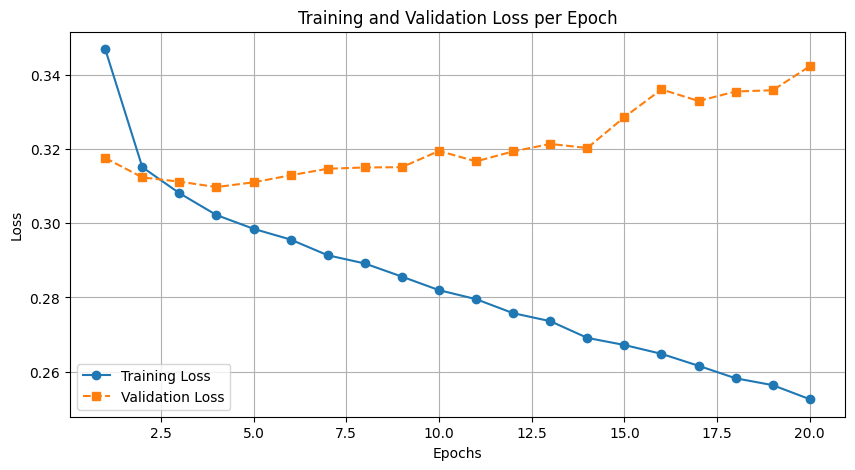

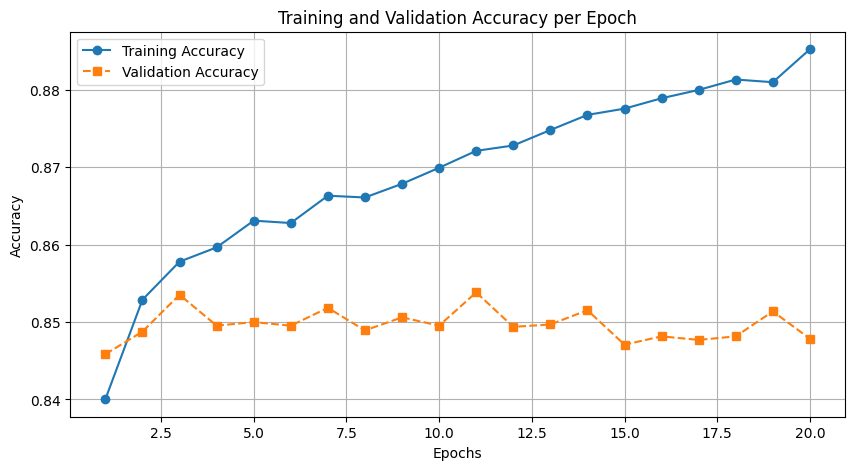

In [11]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_loss, label='Validation Loss', marker='s', linestyle='--')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label='Training Accuracy', marker='o')
plt.plot(range(1, epochs + 1), val_acc, label='Validation Accuracy', marker='s', linestyle='--')
plt.title('Training and Validation Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


#**Summary**


*   We can see in the training process that the validation accuracy reaches its
peaks at **Epoch 11**  (85.38%%). but after that , the validation performance starts to decline while the training accuracy continues to improve.
This indicates the model is overfitting the training data. To avoid overifitting , we should stop the training at **Epoch 11** , where the model achieves its best validation results.

*   The model achieved a **test accuracy of  84.17%** , which means we successfully  break the current benchmarks by Logistic Regression and SVM.









# **Part 2 : Multi Class Classification:**

 In this part we will predict Clothes Categories Using a Feed Forward Neural Network for the FashionMNIST  dataset.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# **Loading and preprocessing the Data:**

 We start by downloading the FashionMNIST dataset and apply the transformations.

Then , we split the dataset into: (80%) for training and (20%) for validation.

In [ ]:
# Define transformations for preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Download and load the FashionMNIST dataset
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split training data into training and validation sets
train_size = int(0.8 * len(train_data))  # 80% for training
val_size = len(train_data) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 20.7MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



**Create Data Loaders:**

we start by creating Data Loaders for training, validation and testing datasets.

Then , we filter the datasets to take only the first 4 categories of lables for Network 1 (we will define it later) and create a seperate Data Loaders for training,validation and testing for the filtered datasets for Network 1 .

In [ ]:
# Create data loaders

from torch.utils.data import Subset

def filter_dataset(dataset, allowed_labels):
    indices = [i for i, (_, label) in enumerate(dataset) if label in allowed_labels]
    return Subset(dataset, indices)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


# Filter training and validation datasets for Network 1 (first 4 categories)
allowed_labels = [0, 1, 2, 3]
train_dataset_1 = filter_dataset(train_dataset, allowed_labels)
val_dataset_1 = filter_dataset(val_dataset, allowed_labels)
test_dataset_1 = filter_dataset(test_data, allowed_labels)

# Create DataLoaders for Network 1
train_loader_1 = DataLoader(train_dataset_1, batch_size=batch_size, shuffle=True)
val_loader_1 = DataLoader(val_dataset_1, batch_size=batch_size, shuffle=False)
test_loader_1 = DataLoader(test_dataset_1, batch_size=batch_size, shuffle=False)






# **Defining the Model :**

## First Feed Forward Netwrok : Netwrok 1

The first network will be a 2-layer network designed to classify the first 4 categoris of the dataset.

**Structure:**

input: 784 ( 28x28 flattened image)

Output layer= Fully connected layer with 4 outputs.

**Total num of Parameters:**

number of weights : 784x4 =3136

number of baises: 4

total parameters: 3136+4 = 3140


In [ ]:

class Network1(nn.Module):
    def __init__(self):
        super(Network1, self).__init__()
        self.fc1 = nn.Linear(784,4)  # First layer: 784 → 4


    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten 28x28 images into 1D vector
        x = self.fc1(x)  # Output
        return x


# **Secound  Feed Forward Netwrok : Netwrok 2**

The secound network will be a 4 layer netwrok designed to classify all the 10 categories of the dataset.

**Structure:**

Input: 784 (28x28 flatterned image)<br>
Hidden Layers:<br>
First layer: 120 neurons. (784->60) <br>
Secound layer: 80 neurons. (784->40)<br>
Third layer: 60 neurons. (40->10) <br>
Output: 10 neurons  for 10 categories. <br>

Activation function : **ReLU** for both hidden layers.

**Total num of Parameters:**

first layer : 784x60+60=47040.<br>
second Layer: 60x40+40=2440.<br>
third Layer :40x10+40=410<br>

Total Parameters: 47040+2440+410 =49890 < 60k


In [ ]:
class Network2(nn.Module):
    def __init__(self):
        super(Network2, self).__init__()
        self.fc1 = nn.Linear(784, 60)  # First layer: 784 → 60
        self.fc2 = nn.Linear(60, 40)  # Second layer: 60 → 40
        self.fc3 = nn.Linear(40, 10)  # Third layer: 40 → 10


    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten 28x28 images into 1D vector
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # Output
        return x


#**Training the model:**



In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs,device):

    model.to(device)
    # Store metrics
    train_loss = []
    val_loss = []
    train_acc = []
    val_acc = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        correct_train = 0
        total_train = 0
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update training metrics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss.append(running_loss / len(train_loader))
        train_acc.append(correct_train / total_train)

        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss.append(val_running_loss / len(val_loader))
        val_acc.append(correct_val / total_val)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]*100:.2f}%, "
              f"Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]*100:.2f}%")

    return train_loss, val_loss, train_acc, val_acc



# **For both Networks we choosed :**


1.    **Hyperparameters:**

      Learning Rate: 0.001.<br>
      Epochs 20.<br>
      Batch size : 64 . <br>
      Weight Decay (L2 Regulariztion) : 1e-4.<br>

2.   **Loss Function :** Cross Entropy Loss.

3.   **Optimizer:** Adam optmizer.


**Experimenting with different Hyperparameters:**

1. Learning Rate: we start by using a higher learning rate (0.01) , but resulted in unstable training with poor convergence. So , we choose to lower the learning rate to 0.001 and get more stabilize training and achieve better convergence over 20 epochs.

2. Optimizer: we tried to use SGD optimizer to see the difference between the results , but it resulted in slower convergence and required more epochs to achieve similar results of the Adam optimizer ,due to its ability to adapt training rate during training.

3. Regularization: without using the regularization method (weight decay) we get more overfitting .So ,in order to reduce the risk of  overfitting we use Weight decay method with L2 regularization to allow the network to generalize better on validation and test sets.  .

4. Batch Size : we tried smaller batch size (16) but we get noisier gradients and slower convergence. So, the chosen batch size (64) balance  between computational efficiency and stable gradient updates.






In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Instantiate models
model1 = Network1()  # Network 1 for 4 categories
model2 = Network2()  # Network 2 for all 10 categories

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001, weight_decay=1e-4)  # With L2 regularization
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)

# Training parameters
epochs = 20

# Train both networks
print("Training Network 1:")
train_loss1, val_loss1, train_acc1, val_acc1 = train_model(model1, train_loader_1, val_loader_1, optimizer1, criterion, epochs,device)

print("\nTraining Network 2:")
train_loss2, val_loss2, train_acc2, val_acc2 = train_model(model2, train_loader, val_loader, optimizer2, criterion, epochs,device)


Training Network 1:
Epoch 1/20, Train Loss: 0.3115, Train Acc: 90.13%, Val Loss: 0.2442, Val Acc: 91.54%
Epoch 2/20, Train Loss: 0.2186, Train Acc: 93.05%, Val Loss: 0.2155, Val Acc: 92.58%
Epoch 3/20, Train Loss: 0.2071, Train Acc: 93.26%, Val Loss: 0.2147, Val Acc: 92.73%
Epoch 4/20, Train Loss: 0.1987, Train Acc: 93.72%, Val Loss: 0.2085, Val Acc: 92.98%
Epoch 5/20, Train Loss: 0.1937, Train Acc: 93.79%, Val Loss: 0.1997, Val Acc: 93.56%
Epoch 6/20, Train Loss: 0.1955, Train Acc: 94.01%, Val Loss: 0.2200, Val Acc: 92.92%
Epoch 7/20, Train Loss: 0.1929, Train Acc: 93.80%, Val Loss: 0.1968, Val Acc: 93.56%
Epoch 8/20, Train Loss: 0.1836, Train Acc: 93.97%, Val Loss: 0.1961, Val Acc: 93.50%
Epoch 9/20, Train Loss: 0.1824, Train Acc: 94.24%, Val Loss: 0.2300, Val Acc: 92.14%
Epoch 10/20, Train Loss: 0.1809, Train Acc: 94.13%, Val Loss: 0.1972, Val Acc: 93.29%
Epoch 11/20, Train Loss: 0.1770, Train Acc: 94.30%, Val Loss: 0.2170, Val Acc: 92.48%
Epoch 12/20, Train Loss: 0.1774, Train Acc:

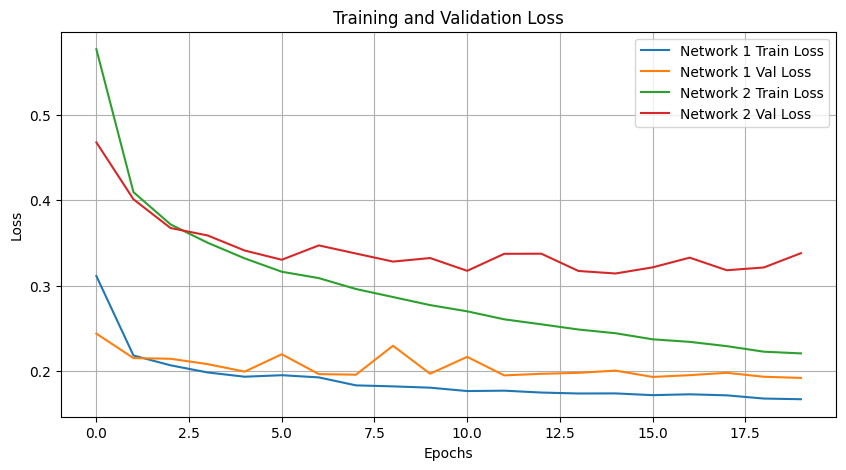

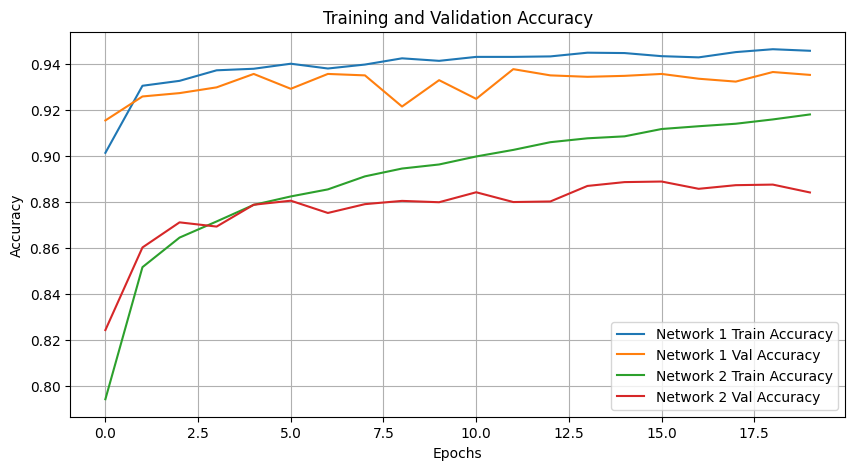

In [ ]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss1, label='Network 1 Train Loss')
plt.plot(val_loss1, label='Network 1 Val Loss')
plt.plot(train_loss2, label='Network 2 Train Loss')
plt.plot(val_loss2, label='Network 2 Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_acc1, label='Network 1 Train Accuracy')
plt.plot(val_acc1, label='Network 1 Val Accuracy')
plt.plot(train_acc2, label='Network 2 Train Accuracy')
plt.plot(val_acc2, label='Network 2 Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

#**Explanation of Training Results:**.

for both networks, the results show that the validation accuracy stabilizes or begins to decrease in the later epochs, which indicates the model starts to overfit the data.



**1.   Network 1 :**


  *   Training accuracy steadily improves, reaching **94.57%** at **Epoch 20**, with a corresponding decrease in training loss. which indicates effective learning on the training data.
    

  *   The validation accuracy peaks at **Epoch 12 (93.77%)** , and the validation loss stabilizes and slightly change afterward .  After **Epoch 12** , validation loss and accuracy start to show small changes, which indicates that the model begins to overfit the training data.
  


     




**2.    Network 2:**




  *   Training accuracy steadily improves, reaching **91.80%** at **Epoch 20**.

  *   The validation accuracy peaks at **Epoch 16 (88.88%)** , with the validation loss decreasing until Epoch 14  and then  slightly changed.  After **Epoch 16** , validation accuracy stabilizes or slightly drops , and the validation loss begins to increase , indicating overfitting .
  




For both networks , early stopping should applied to avoid overfitting :<br>  for **Network 1** , stopping around **Epoch 12** and for **Network 2** , stopping at **Epoch16** is optimal to balance between training and validation performance.



##**Model Evaluation :**

In [ ]:
def evaluate_model(model, loader, criterion, device):
    model=model.to(device)
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return running_loss / len(loader), accuracy



In [ ]:
# Evaluate Network 1
test_loss1, test_acc1 = evaluate_model(model1, test_loader_1, criterion,device)
print(f"Network 1 - Test Loss: {test_loss1:.4f}, Test Accuracy: {test_acc1 * 100:.2f}%")

# Evaluate Network 2
test_loss2, test_acc2 = evaluate_model(model2, test_loader, criterion,device)
print(f"Network 2 - Test Loss: {test_loss2:.4f}, Test Accuracy: {test_acc2 * 100:.2f}%")


Network 1 - Test Loss: 0.2159, Test Accuracy: 93.25%
Network 2 - Test Loss: 0.3786, Test Accuracy: 86.88%


## Test Results Summary:



1.   Network 1 :  Test Loss : 0.2159 , Test Accuracy: 93.25%.
2.   Network 2 :  Test Loss:  0.3786,  Test Accuracy: 86.88%.



**Comparing the performance of the two networks:**


  We can see that the test accuracy for Network 1 is higher compared to the Network 2 , This can be attributed to the following reasons:


1. Network 1 has a simpler architecture with only 2 layers and 3140 parameters, making it easier to train and learn optimal weights effectively. <br>
2. Network 1 classifies only 4 classes , which reduces ambiguity and improves performance. <br>
3. Network 2 has a deeper, multi-layer architecture with significantly more number of parameters, making it harder to train effectively and more prone to overfitting or needing more data.
4. Network 2 must classify 10 classes, increasing complexity and requiring the model to distinguish between more overlapping categories which impacts performance.




